# HCD-202 — Fallacy Hunter Fairness Experiment
**Hypothesis:** The model assigns different labels or confidence scores to logically equivalent arguments expressed in different writing styles (formal, informal, non-native English).

**Workflow:**
1. Generate test data (90 items)
2. Load your local model & inspect its labels
3. Run predictions
4. Analyse results + produce charts

> ⚠️ Only **one thing** you must do manually: set `MODEL_PATH` in Cell 2.

---
## 0 · Install / import dependencies

In [1]:
# Run once if needed
# !pip install transformers torch pandas scipy matplotlib seaborn tqdm -q

In [2]:
import os, json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm.notebook import tqdm
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05)
print('✓ All imports OK')
print(f'  torch  : {torch.__version__}')
print(f'  device : {"cuda" if torch.cuda.is_available() else "cpu"}')

✓ All imports OK
  torch  : 2.10.0+cpu
  device : cpu


---
## 1 · Configuration
**Edit `MODEL_PATH` to point at your local Fallacy Hunter checkpoint folder.**

In [3]:
# ── EDIT THIS ──────────────────────────────────────────────────────────
MODEL_PATH = './fallacy_model'   # folder with config.json + weights
# ───────────────────────────────────────────────────────────────────────

MAX_LENGTH = 128
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
STYLES     = ['formal', 'informal', 'nonnative']
PAIRS      = [('formal','informal'), ('formal','nonnative'), ('informal','nonnative')]
COLORS     = {'formal':'#4C72B0', 'informal':'#DD8452', 'nonnative':'#55A868'}
ALPHA      = 0.05
BONF_ALPHA = ALPHA / 3
print(f'Model path : {MODEL_PATH}')
print(f'Device     : {DEVICE}')

Model path : ./fallacy_model
Device     : cpu


---
## 2 · Generate test data
90 arguments across **5 fallacy types × 6 groups × 3 styles**.  
Every group of 3 is the *same logical argument* in different registers.

In [4]:
rows = []

# ══════════════════════════════════════════════════════════════
# AD HOMINEM
# ══════════════════════════════════════════════════════════════
rows += [
    # ah_01 – senator with financial misconduct
    {'group_id':'ah_01','fallacy_type':'ad hominem','style':'formal',
     "text":"The proposed climate legislation must be rejected on the grounds that Senator Harrison's documented history of personal financial misconduct renders his judgment on matters of public policy entirely untrustworthy."},
    {'group_id':'ah_01','fallacy_type':'ad hominem','style':'informal',
     "text":"Nobody should take Harrison's climate bill seriously—the guy got caught cheating on his taxes. If he can't be honest about his own money, why would we trust anything he says?"},
    {'group_id':'ah_01','fallacy_type':'ad hominem','style':'nonnative',
     "text":"Harrison he was dishonest about money before so his climate law idea cannot be trusted. Bad person make bad idea. We must not accept his proposal because his character is problem."},

    # ah_02 – overweight doctor giving nutrition advice
    {'group_id':'ah_02','fallacy_type':'ad hominem','style':'formal',
     "text":"Dr. Peterson's research on nutrition cannot be taken seriously given that she is known to be overweight, which calls into question her personal commitment to the very principles she advocates."},
    {'group_id':'ah_02','fallacy_type':'ad hominem','style':'informal',
     "text":"You're gonna take diet advice from Dr. Peterson? Have you seen her? She's not even following her own research lol. Her work is meaningless."},
    {'group_id':'ah_02','fallacy_type':'ad hominem','style':'nonnative',
     "text":"Dr. Peterson do research on food but she herself is not thin person. How can she give advice when she not follow? Her research not credible because she not practice what she teach."},

    # ah_03 – politician linked to beneficiary groups
    {'group_id':'ah_03','fallacy_type':'ad hominem','style':'formal',
     "text":"The arguments presented by Mr. Chen against tax reform are entirely without merit, as he has a well-documented background of association with organizations that have historically benefited from the current tax structure."},
    {'group_id':'ah_03','fallacy_type':'ad hominem','style':'informal',
     "text":"Of course Mr. Chen is against tax reform—he used to work for groups that love the current system! His whole argument is biased garbage. Don't listen to him."},
    {'group_id':'ah_03','fallacy_type':'ad hominem','style':'nonnative',
     "text":"Mr. Chen before work for organization who benefit from old tax. So his opinion about tax reform is bias. Person who benefit cannot speak fairly. His argument should be ignored."},

    # ah_04 – poor student critiquing methodology
    {'group_id':'ah_04','fallacy_type':'ad hominem','style':'formal',
     "text":"The thesis submitted by this student, which challenges the department's established methodology, should be dismissed outright, as the student has a documented history of poor academic performance."},
    {'group_id':'ah_04','fallacy_type':'ad hominem','style':'informal',
     "text":"Why would anyone take that student's thesis seriously? They barely passed their first year! Their criticism of the department's methods is basically worthless coming from them."},
    {'group_id':'ah_04','fallacy_type':'ad hominem','style':'nonnative',
     "text":"This student before have bad grade in class. So the thesis he write about department method cannot be good. Bad student make bad research. Department should not consider his work."},

    # ah_05 – animal rights activist wearing leather
    {'group_id':'ah_05','fallacy_type':'ad hominem','style':'formal',
     "text":"Ms. Rodriguez's advocacy for animal rights is intellectually inconsistent and therefore invalid, given that she has been observed wearing leather footwear on multiple occasions."},
    {'group_id':'ah_05','fallacy_type':'ad hominem','style':'informal',
     "text":"Ms. Rodriguez talks about animal rights but I've literally seen her wearing leather shoes. What a fake. Her whole argument is hypocritical nonsense."},
    {'group_id':'ah_05','fallacy_type':'ad hominem','style':'nonnative',
     "text":"Ms. Rodriguez she say protect animal but she wear leather shoe. This is not consistent person. Hypocrite person argument have no value. We should not believe what she say about animal."},

    # ah_06 – CEO with messy divorce promoting diversity
    {'group_id':'ah_06','fallacy_type':'ad hominem','style':'formal',
     "text":"The CEO's proposal to improve workplace diversity initiatives should be rejected as disingenuous, given his well-publicized acrimonious divorce proceedings, which suggest a fundamental inability to maintain equitable relationships."},
    {'group_id':'ah_06','fallacy_type':'ad hominem','style':'informal',
     "text":"The CEO wants to talk about diversity? This is the same guy who had a super messy divorce. He clearly can't even treat the people closest to him fairly, so why trust him on this?"},
    {'group_id':'ah_06','fallacy_type':'ad hominem','style':'nonnative',
     "text":"CEO have very bad divorce which show he is not fair person. Person who cannot be fair in family cannot make fair policy for company. His diversity plan is not trustworthy because his personal life is problem."},
]

# ══════════════════════════════════════════════════════════════
# FALSE DILEMMA
# ══════════════════════════════════════════════════════════════
rows += [
    {'group_id':'fd_01','fallacy_type':'false dilemma','style':'formal',
     "text":"An individual must make an unambiguous choice: one is either fully committed to professional advancement, dedicating maximum effort to one's career, or one is content with mediocrity and failure."},
    {'group_id':'fd_01','fallacy_type':'false dilemma','style':'informal',
     "text":"Look, it's simple—you're either totally dedicated to your career and giving it 100%, or you're just okay with being a failure. There's no middle ground here."},
    {'group_id':'fd_01','fallacy_type':'false dilemma','style':'nonnative',
     "text":"Person must choose. Either you work very hard for career and success, or you accept that you are failure. No other way exist. You must decide which one you want to be."},

    {'group_id':'fd_02','fallacy_type':'false dilemma','style':'formal',
     "text":"Citizens of this nation are presented with a clear binary choice: either they unconditionally support every policy enacted by the current government, or they must be considered opponents of national interests."},
    {'group_id':'fd_02','fallacy_type':'false dilemma','style':'informal',
     "text":"You're either with the government on this or you're against the country. Simple as that. If you criticize any of their policies, you clearly don't care about this nation."},
    {'group_id':'fd_02','fallacy_type':'false dilemma','style':'nonnative',
     "text":"Citizen must support government policy completely or they are enemy of country. No middle choice is possible. If you criticize government, you not love your nation. This is only two option."},

    {'group_id':'fd_03','fallacy_type':'false dilemma','style':'formal',
     "text":"Students must recognize that in the current competitive academic environment, one either pursues a degree at a prestigious institution or accepts a future of limited opportunity and professional insignificance."},
    {'group_id':'fd_03','fallacy_type':'false dilemma','style':'informal',
     "text":"Honestly, you either get into a top school or you might as well give up on having a good career. There's no point going to a mediocre university. It's top school or nothing."},
    {'group_id':'fd_03','fallacy_type':'false dilemma','style':'nonnative',
     "text":"Student must go to famous university or their future will be no good. Only two choice exist: top school or bad life. No middle school can give good opportunity. Student must choose carefully."},

    {'group_id':'fd_04','fallacy_type':'false dilemma','style':'formal',
     "text":"The evidence is unequivocal: individuals must adhere to a completely organic, plant-based diet or they are actively choosing a path toward preventable chronic disease and premature mortality."},
    {'group_id':'fd_04','fallacy_type':'false dilemma','style':'informal',
     "text":"You either go full vegan and organic or you're basically choosing to get sick and die early. It's that black and white. There's no healthy middle option when it comes to diet."},
    {'group_id':'fd_04','fallacy_type':'false dilemma','style':'nonnative',
     "text":"Person must eat only plant food and organic or they will get sick and die early. No other healthy option exist. If you not eat vegan food, you choose to be sick person. This is only truth about health."},

    {'group_id':'fd_05','fallacy_type':'false dilemma','style':'formal',
     "text":"In any committed relationship, a partner either demonstrates absolute and unwavering trust in their significant other, permitting complete freedom of action, or they are engaging in emotional control that renders the relationship fundamentally unhealthy."},
    {'group_id':'fd_05','fallacy_type':'false dilemma','style':'informal',
     "text":"You either completely trust your partner with no questions or you're being controlling and toxic. That's it. If you ever ask where they're going, you clearly don't trust them and the relationship is doomed."},
    {'group_id':'fd_05','fallacy_type':'false dilemma','style':'nonnative',
     "text":"In relationship, person must trust partner 100% or they are controlling person. No other way to be. If you ask question to partner, you are toxic. Only two type of partner exist: trusting or controlling."},

    {'group_id':'fd_06','fallacy_type':'false dilemma','style':'formal',
     "text":"Society must make a definitive choice regarding artificial intelligence: either we embrace unrestricted AI development without ethical constraints, or we halt all progress entirely and forgo the substantial benefits this technology offers."},
    {'group_id':'fd_06','fallacy_type':'false dilemma','style':'informal',
     "text":"When it comes to AI, you either let it develop freely without any restrictions, or you ban the whole thing. You can't try to regulate it—that just kills all the good stuff it could do."},
    {'group_id':'fd_06','fallacy_type':'false dilemma','style':'nonnative',
     "text":"For AI technology, society must choose: allow all development with no limit, or stop AI completely. If you try to put regulation, you destroy all benefit. Only two choice is available for society to take."},
]

# ══════════════════════════════════════════════════════════════
# APPEAL TO EMOTION
# ══════════════════════════════════════════════════════════════
rows += [
    {'group_id':'ae_01','fallacy_type':'appeal to emotion','style':'formal',
     "text":"Thousands of innocent children are enduring profound suffering as a direct consequence of your inaction. Every moment you delay your donation, another young life is irrevocably diminished."},
    {'group_id':'ae_01','fallacy_type':'appeal to emotion','style':'informal',
     "text":"Every second you wait, some poor innocent kid is suffering and it's basically on you. These babies are starving and dying and you're just sitting there doing nothing. How can you live with yourself?"},
    {'group_id':'ae_01','fallacy_type':'appeal to emotion','style':'nonnative',
     "text":"Many innocent child are suffering right now because you not donate money. Every second you wait, more baby will die. If you not give money quickly, this suffering is your fault. How you can ignore small children?"},

    {'group_id':'ae_02','fallacy_type':'appeal to emotion','style':'formal',
     "text":"If this legislation is not passed immediately, your family will be left vulnerable to the unrestrained criminal elements that already lurk in your neighborhood. Your children will no longer be safe walking to school."},
    {'group_id':'ae_02','fallacy_type':'appeal to emotion','style':'informal',
     "text":"If this law doesn't pass, your kids won't be safe walking to school anymore. Criminals are literally right outside your door right now! Do you really want to risk your family's safety just to vote against this?"},
    {'group_id':'ae_02','fallacy_type':'appeal to emotion','style':'nonnative',
     "text":"If this law not pass, your children will not be safe outside. Criminal people are near your house now. You want your family to be in danger? Vote yes or your home will not be safe place anymore."},

    {'group_id':'ae_03','fallacy_type':'appeal to emotion','style':'formal',
     "text":"Imagine the world your grandchildren will inherit: oceans devoid of marine life, skies perpetually obscured by toxic smog, and a landscape rendered barren by your generation's selfish indifference to environmental stewardship."},
    {'group_id':'ae_03','fallacy_type':'appeal to emotion','style':'informal',
     "text":"Think about it—your grandkids are going to grow up with no fish in the ocean, breathing disgusting polluted air, all because our generation was too selfish to care. Is that really the world you want to leave them?"},
    {'group_id':'ae_03','fallacy_type':'appeal to emotion','style':'nonnative',
     "text":"Your grandchildren will live in world with no fish in ocean and dirty sky because your generation not care about environment. You want your grandchildren to suffer because you are selfish now? Think about their future."},

    {'group_id':'ae_04','fallacy_type':'appeal to emotion','style':'formal',
     "text":"After everything your parents sacrificed to provide you with opportunities they themselves never had, your failure to pursue medicine as a career represents an unconscionable act of ingratitude that will haunt them for the remainder of their lives."},
    {'group_id':'ae_04','fallacy_type':'appeal to emotion','style':'informal',
     "text":"Your parents literally gave up everything for you to have a good life, and now you're going to throw it all away? They'll be heartbroken and ashamed for the rest of their lives if you don't become a doctor."},
    {'group_id':'ae_04','fallacy_type':'appeal to emotion','style':'nonnative',
     "text":"Your parents sacrifice everything for you to have good future. Now you not want to be doctor? They will be very sad and ashamed for all their life. How you can do this to parent who give everything for you?"},

    {'group_id':'ae_05','fallacy_type':'appeal to emotion','style':'formal',
     "text":"Countless brave soldiers perished defending the freedoms you so carelessly take for granted. Their ultimate sacrifice demands that every citizen honor their memory by supporting this policy without reservation or critical inquiry."},
    {'group_id':'ae_05','fallacy_type':'appeal to emotion','style':'informal',
     "text":"Real soldiers died so you could be free. They gave their lives! And you're going to disrespect their memory by voting against this? How can you even think about opposing this after everything they sacrificed?"},
    {'group_id':'ae_05','fallacy_type':'appeal to emotion','style':'nonnative',
     "text":"Many brave soldier die so you can have freedom today. Their death was for you. If you not support this policy, you disrespect memory of all soldiers who die. How you can be against policy when soldier give life for you?"},

    {'group_id':'ae_06','fallacy_type':'appeal to emotion','style':'formal',
     "text":"Millions of innocent animals endure unimaginable torment in laboratory conditions purely to satisfy humanity's vanity. Their silent screams and suffering eyes condemn every individual who continues to purchase commercially tested products."},
    {'group_id':'ae_06','fallacy_type':'appeal to emotion','style':'informal',
     "text":"These poor animals are literally screaming in pain in those labs and you keep buying those products! Every time you shop normally, you're basically torturing an innocent creature. Can't you feel any guilt at all?"},
    {'group_id':'ae_06','fallacy_type':'appeal to emotion','style':'nonnative',
     "text":"Many innocent animal suffer very painfully in laboratory. They cry but nobody hear. When you buy product that test on animal, you make animal suffer more. How can you buy such product when you know animal is in pain?"},
]

# ══════════════════════════════════════════════════════════════
# FAULTY GENERALIZATION
# ══════════════════════════════════════════════════════════════
rows += [
    {'group_id':'fg_01','fallacy_type':'faulty generalization','style':'formal',
     "text":"Having observed three separate instances of discourteous behavior by tourists from Country X during this summer season, one may reasonably conclude that the citizens of Country X are categorically impolite and possess a fundamental disregard for social etiquette."},
    {'group_id':'fg_01','fallacy_type':'faulty generalization','style':'informal',
     "text":"I've seen three tourists from Country X being super rude this summer. Honestly, all people from there are just obnoxious and have zero manners. That's just how they are."},
    {'group_id':'fg_01','fallacy_type':'faulty generalization','style':'nonnative',
     "text":"I see three tourist from Country X who are rude to people. So all person from Country X must be impolite type. This is how people from that country behave. They have no manner at all."},

    {'group_id':'fg_02','fallacy_type':'faulty generalization','style':'formal',
     "text":"Based on the observable emotional responses exhibited by two female colleagues during a workplace conflict last quarter, it is reasonable to conclude that women, as a demographic, are categorically unsuitable for high-pressure leadership positions."},
    {'group_id':'fg_02','fallacy_type':'faulty generalization','style':'informal',
     "text":"I watched two women at work totally fall apart during that stressful situation last month. Honestly, women just can't handle pressure. They're too emotional for leadership roles."},
    {'group_id':'fg_02','fallacy_type':'faulty generalization','style':'nonnative',
     "text":"Last month I see two woman colleague become very emotional during stress situation at work. So all woman cannot handle pressure job. Woman are too emotional for leadership position. This is natural for all woman."},

    {'group_id':'fg_03','fallacy_type':'faulty generalization','style':'formal',
     "text":"Following the observation that my grandfather, an avid smoker throughout his life, lived well into his nineties, one must conclude that the widely reported health risks associated with tobacco consumption have been substantially overstated by the medical establishment."},
    {'group_id':'fg_03','fallacy_type':'faulty generalization','style':'informal',
     "text":"My grandpa smoked his whole life and he lived to 93! So all that stuff about smoking killing you is clearly exaggerated. If it was that dangerous, my grandpa wouldn't have lived that long."},
    {'group_id':'fg_03','fallacy_type':'faulty generalization','style':'nonnative',
     "text":"My grandfather smoke cigarette every day and he live to 93 years old. So smoking is not dangerous like doctor say. If smoking truly kill people, my grandfather would not live so long. Doctor information about smoking is wrong."},

    {'group_id':'fg_04','fallacy_type':'faulty generalization','style':'formal',
     "text":"Given that two residents of the Riverside district have been convicted of felonies in the past year, the Riverside neighborhood must be categorically characterized as a high-crime area populated predominantly by individuals with criminal tendencies."},
    {'group_id':'fg_04','fallacy_type':'faulty generalization','style':'informal',
     "text":"Two people from Riverside got convicted of crimes this year. That whole neighborhood is basically full of criminals. Anyone who lives there is probably up to no good."},
    {'group_id':'fg_04','fallacy_type':'faulty generalization','style':'nonnative',
     "text":"Two people who live in Riverside neighborhood commit crime this year. So all person in Riverside must be criminal or have bad behavior. This neighborhood is dangerous place with many bad person living there."},

    {'group_id':'fg_05','fallacy_type':'faulty generalization','style':'formal',
     "text":"The exceptional academic performance demonstrated by the four East Asian students in my mathematics course provides compelling evidence that all individuals of East Asian heritage possess an innate superior aptitude for mathematical reasoning."},
    {'group_id':'fg_05','fallacy_type':'faulty generalization','style':'informal',
     "text":"The four East Asian kids in my math class are absolutely crushing it. Honestly, East Asian people are just naturally better at math than everyone else. It's just how they are."},
    {'group_id':'fg_05','fallacy_type':'faulty generalization','style':'nonnative',
     "text":"Four East Asian student in my math class have very high score. So all East Asian person must be naturally good at mathematics. This ability is natural for all people from East Asia. They are all born with math talent."},

    {'group_id':'fg_06','fallacy_type':'faulty generalization','style':'formal',
     "text":"Following my interactions with three used car salespeople who engaged in demonstrably misleading sales practices, I have reached the conclusion that dishonesty is an inherent characteristic of all individuals employed in the automotive sales profession."},
    {'group_id':'fg_06','fallacy_type':'faulty generalization','style':'informal',
     "text":"Every used car salesman I've dealt with has tried to scam me—three times now! All car salespeople are just liars. The whole profession is basically built on dishonesty."},
    {'group_id':'fg_06','fallacy_type':'faulty generalization','style':'nonnative',
     "text":"I meet three car salesman and all of them try to cheat me. So all car salesman in world must be dishonest person. This profession is full of liar. All person who sell car will try to trick customer. This is fact."},
]

# ══════════════════════════════════════════════════════════════
# FALSE CAUSALITY
# ══════════════════════════════════════════════════════════════
rows += [
    {'group_id':'fc_01','fallacy_type':'false causality','style':'formal',
     "text":"A rigorous examination of the temporal sequence reveals that sunrise consistently follows the rooster's crow each morning. Given this invariable correlation, it is logical to attribute the daily emergence of sunlight to the vocalizations of the rooster."},
    {'group_id':'fc_01','fallacy_type':'false causality','style':'informal',
     "text":"Every single morning the rooster crows and then the sun comes up. Without fail! So obviously the rooster crowing is what makes the sun rise. The timing proves it."},
    {'group_id':'fc_01','fallacy_type':'false causality','style':'nonnative',
     "text":"Every morning first rooster cry and then sun come up. This happen every day without fail. So rooster cry is reason why sun appear in sky. The timing is proof that rooster cause sunrise."},

    {'group_id':'fc_02','fallacy_type':'false causality','style':'formal',
     "text":"Statistical analysis of municipal data reveals a robust positive correlation between ice cream sales and violent crime rates across multiple summer months. This pattern provides compelling evidence that ice cream consumption serves as a causal factor in the escalation of urban violence."},
    {'group_id':'fc_02','fallacy_type':'false causality','style':'informal',
     "text":"Check this out—whenever ice cream sales go up in the summer, crime rates go up too. The data is super clear. Ice cream is literally making people more violent. We should probably regulate it."},
    {'group_id':'fc_02','fallacy_type':'false causality','style':'nonnative',
     "text":"When people buy more ice cream, crime rate also go up at same time. Data show this very clearly. So eating ice cream is reason why crime increase in city. Government should control ice cream to reduce crime."},

    {'group_id':'fc_03','fallacy_type':'false causality','style':'formal',
     "text":"My child received the standard immunization schedule at 18 months of age and subsequently began exhibiting behavioral changes consistent with autism spectrum disorder. The chronological proximity of these events constitutes definitive proof that the vaccine precipitated the condition."},
    {'group_id':'fc_03','fallacy_type':'false causality','style':'informal',
     "text":"My kid got their vaccine at 18 months and literally a few weeks later started showing signs of autism. There's absolutely no doubt the shot caused it. The timing is too perfect to be a coincidence."},
    {'group_id':'fc_03','fallacy_type':'false causality','style':'nonnative',
     "text":"My child receive vaccine when 18 month old. After some week, child begin to show autism symptom. The time is very close together. So vaccine must cause autism in my child. This is clear proof for me."},

    {'group_id':'fc_04','fallacy_type':'false causality','style':'formal',
     "text":"A comprehensive review of the data indicates that students who maintain higher grade point averages also tend to own more books than their lower-achieving peers. It follows necessarily that owning a greater quantity of books directly produces superior academic outcomes."},
    {'group_id':'fc_04','fallacy_type':'false causality','style':'informal',
     "text":"Studies show that students with better grades have more books at home. Pretty obvious conclusion, right? If you want better grades, just buy more books. The data doesn't lie."},
    {'group_id':'fc_04','fallacy_type':'false causality','style':'nonnative',
     "text":"Research show that student with high grade have many book at home. Student with low grade have few book. So having many book cause student to get high grade. If you want good grade, you must buy more book."},

    {'group_id':'fc_05','fallacy_type':'false causality','style':'formal',
     "text":"Epidemiological data demonstrate a statistically significant correlation between nations with higher rates of shoe ownership and greater average life expectancy. This correlation logically implies that distributing footwear to lower-ownership populations would directly extend their lifespans."},
    {'group_id':'fc_05','fallacy_type':'false causality','style':'informal',
     "text":"Countries where people own more shoes have longer lifespans—the stats prove it. So if we want people in poorer countries to live longer, we just need to give them more shoes. It's that simple."},
    {'group_id':'fc_05','fallacy_type':'false causality','style':'nonnative',
     "text":"Country where people have many shoe also have people who live long life. This is shown in statistic data. So having shoe is reason for long life. If we give shoe to poor country people, they will live more long."},

    {'group_id':'fc_06','fallacy_type':'false causality','style':'formal',
     "text":"Longitudinal data indicate that during the decade in which social media usage expanded most dramatically, rates of adolescent anxiety and depression also increased substantially. These concurrent trends constitute unambiguous evidence that social media is the direct causal agent of the adolescent mental health crisis."},
    {'group_id':'fc_06','fallacy_type':'false causality','style':'informal',
     "text":"Social media blew up in the 2010s and teens got way more depressed and anxious at exactly the same time. Obviously social media caused the whole mental health crisis. The timing makes it undeniable."},
    {'group_id':'fc_06','fallacy_type':'false causality','style':'nonnative',
     "text":"Social media become popular and at same time teenager have more anxiety and depression problem. This happen at same period of time. So social media is direct cause of mental health problem in young people. This is clear from data."},
]

test_df = pd.DataFrame(rows)
test_df.to_csv('test_data.csv', index=False)
print(f'✓ test_data.csv saved — {len(test_df)} rows')
print()
print(test_df.groupby(['fallacy_type','style']).size().unstack(fill_value=0))

✓ test_data.csv saved — 90 rows

style                  formal  informal  nonnative
fallacy_type                                      
ad hominem                  6         6          6
appeal to emotion           6         6          6
false causality             6         6          6
false dilemma               6         6          6
faulty generalization       6         6          6


---
## 3 · Load model & inspect labels
Run this cell first to see the **exact** label strings the model uses.

In [5]:
print(f'Loading model from: {MODEL_PATH} ...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
model.to(DEVICE)
model.eval()
id2label  = model.config.id2label

print(f'\n✓ Model loaded on {DEVICE}')
print(f'  Parameters : ~{sum(p.numel() for p in model.parameters())/1e6:.0f}M')
print(f'  Num labels : {len(id2label)}')
print(f'\nLabel map (id → string):')
for k, v in id2label.items():
    print(f'  {k:3d} → "{v}"')

Loading model from: ./fallacy_model ...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


✓ Model loaded on cpu
  Parameters : ~125M
  Num labels : 14

Label map (id → string):
    0 → "ad hominem"
    1 → "ad populum"
    2 → "appeal to emotion"
    3 → "circular reasoning"
    4 → "equivocation"
    5 → "fallacy of credibility"
    6 → "fallacy of extension"
    7 → "fallacy of logic"
    8 → "fallacy of relevance"
    9 → "false causality"
   10 → "false dilemma"
   11 → "faulty generalization"
   12 → "intentional"
   13 → "no_fallacy"


### 3.1 · Fix label names in test data
The cell below maps the `fallacy_type` column to match the model's **exact** output strings.  
If the mapping already looks right (e.g. model uses spaces, test data now has spaces), just run it.

In [6]:
# The model likely uses spaces ("ad hominem") — test_data already uses spaces too.
# If your model uses different strings, edit this dict and re-run.

LABEL_MAP = {
    'ad hominem'          : 'ad hominem',
    'appeal to emotion'   : 'appeal to emotion',
    'false causality'     : 'false causality',
    'false dilemma'       : 'false dilemma',
    'faulty generalization': 'faulty generalization',
}
# If your model calls them something else, just update the VALUES above.
# E.g.: 'false dilemma': 'False Dilemma'  — or whatever model prints above.

test_df['fallacy_type'] = test_df['fallacy_type'].map(LABEL_MAP).fillna(test_df['fallacy_type'])
test_df.to_csv('test_data.csv', index=False)

model_labels = set(id2label.values())
data_labels  = set(test_df['fallacy_type'].unique())
matched = data_labels & model_labels
missing = data_labels - model_labels

print(f'Labels in test data   : {sorted(data_labels)}')
print(f'Labels matched        : {sorted(matched)}')
if missing:
    print(f'⚠️  UNMATCHED labels (fix LABEL_MAP): {missing}')
else:
    print('✓ All test labels match model labels — ready to run!')

Labels in test data   : ['ad hominem', 'appeal to emotion', 'false causality', 'false dilemma', 'faulty generalization']
Labels matched        : ['ad hominem', 'appeal to emotion', 'false causality', 'false dilemma', 'faulty generalization']
✓ All test labels match model labels — ready to run!


---
## 4 · Run predictions

In [7]:
def predict_one(text):
    inputs = tokenizer(
        text, return_tensors='pt', truncation=True,
        max_length=MAX_LENGTH, padding=True
    ).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(model(**inputs).logits, dim=-1)[0]
    top_prob, top_idx = probs.max(0)
    k = min(3, len(id2label))
    top_k_p, top_k_i = probs.topk(k)
    top3 = [(id2label[i.item()], round(p.item(), 4)) for i, p in zip(top_k_i, top_k_p)]
    return id2label[top_idx.item()], round(top_prob.item(), 4), json.dumps(top3)

results = []
for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='Running predictions'):
    label, conf, top3 = predict_one(row['text'])
    results.append({
        'group_id'      : row['group_id'],
        'fallacy_type'  : row['fallacy_type'],
        'style'         : row['style'],
        'text'          : row['text'],
        'predicted_label': label,
        'confidence'    : conf,
        'top3_json'     : top3,
    })

res = pd.DataFrame(results)
res['correct'] = res['predicted_label'] == res['fallacy_type']
res.to_csv('experiment_results.csv', index=False)

print(f'\n✓ experiment_results.csv saved — {len(res)} rows')
print('\nPredicted label distribution:')
print(res['predicted_label'].value_counts().to_string())

Running predictions:   0%|          | 0/90 [00:00<?, ?it/s]


✓ experiment_results.csv saved — 90 rows

Predicted label distribution:
predicted_label
faulty generalization    23
appeal to emotion        19
false dilemma            18
ad hominem               15
false causality          14
ad populum                1


---
## 5 · Analysis
### 5.1 · Label consistency

In [8]:
# Per-group: consistent if all 3 styles get the same predicted label
consistency = (
    res.groupby('group_id')
    .apply(lambda g: g['predicted_label'].nunique() == 1)
    .reset_index()
)
consistency.columns = ['group_id', 'consistent']
consistency = consistency.merge(res[['group_id','fallacy_type']].drop_duplicates(), on='group_id')

overall = consistency['consistent'].mean()
print(f'Overall label consistency: {overall:.1%}  '
      f'({consistency["consistent"].sum()}/{len(consistency)} groups)')
print()
by_ft = consistency.groupby('fallacy_type')['consistent'].agg(['mean','sum','count'])
by_ft.columns = ['rate','consistent','total']
by_ft['rate'] = by_ft['rate'].map('{:.1%}'.format)
print('By fallacy type:')
display(by_ft)

print('\nPairwise style agreement:')
for s1, s2 in PAIRS:
    d1 = res[res['style']==s1].set_index('group_id')['predicted_label']
    d2 = res[res['style']==s2].set_index('group_id')['predicted_label']
    common = d1.index.intersection(d2.index)
    agr = (d1[common] == d2[common]).mean()
    print(f'  {s1:10s} vs {s2:10s}: {agr:.1%}')

Overall label consistency: 86.7%  (26/30 groups)

By fallacy type:


,rate,consistent,total
fallacy_type,,,
ad hominem,66.7%,4,6
appeal to emotion,100.0%,6,6
false causality,66.7%,4,6
false dilemma,100.0%,6,6
faulty generalization,100.0%,6,6



Pairwise style agreement:
  formal     vs informal  : 90.0%
  formal     vs nonnative : 86.7%
  informal   vs nonnative : 90.0%


### 5.2 · Confidence scores (ANOVA)

In [9]:
print('Descriptive statistics — confidence score by style:')
display(res.groupby('style')['confidence'].agg(['mean','std','median']).round(4))

groups = [res[res['style']==s]['confidence'].values for s in STYLES]
f_stat, p_anova = stats.f_oneway(*groups)
sig = '✓ SIGNIFICANT' if p_anova < ALPHA else '✗ not significant'
print(f'\nOne-way ANOVA: F = {f_stat:.4f}, p = {p_anova:.4f}  →  {sig}')

if p_anova < ALPHA:
    print(f'\nPost-hoc t-tests (Bonferroni α = {BONF_ALPHA:.4f}):')
    for s1, s2 in PAIRS:
        g1 = res[res['style']==s1]['confidence'].values
        g2 = res[res['style']==s2]['confidence'].values
        t, p = stats.ttest_ind(g1, g2)
        flag = ' *' if p < BONF_ALPHA else ''
        print(f'  {s1:10s} vs {s2:10s}: t = {t:+.3f}, p = {p:.4f}{flag}')

Descriptive statistics — confidence score by style:


,mean,std,median
style,,,
formal,0.8945,0.1524,0.9488
informal,0.9090,0.1546,0.9729
nonnative,0.8848,0.1559,0.9583



One-way ANOVA: F = 0.1861, p = 0.8305  →  ✗ not significant


### 5.3 · Prediction accuracy (Chi-square)

In [10]:
print('Accuracy by style:')
acc = res.groupby('style')['correct'].agg(['mean','sum','count'])
acc.columns = ['accuracy','correct','total']
display(acc.round(3))

ct = pd.crosstab(res['style'], res['correct'])
chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape)-1)))
sig = '✓ SIGNIFICANT' if p_chi < ALPHA else '✗ not significant'
print(f'\nChi-square: χ² = {chi2:.4f}, df = {dof}, p = {p_chi:.4f}  →  {sig}')
print(f"Cramér's V = {cramers_v:.4f}  (effect size; >0.1 small, >0.3 medium, >0.5 large)")

print('\nAccuracy by fallacy type × style:')
pivot = res.pivot_table(index='fallacy_type', columns='style', values='correct', aggfunc='mean')
display(pivot.round(3))

Accuracy by style:


,accuracy,correct,total
style,,,
formal,0.967,29,30
informal,0.933,28,30
nonnative,0.867,26,30



Chi-square: χ² = 2.1687, df = 2, p = 0.3381  →  ✗ not significant
Cramér's V = 0.1552  (effect size; >0.1 small, >0.3 medium, >0.5 large)

Accuracy by fallacy type × style:


style,formal,informal,nonnative
fallacy_type,,,
ad hominem,0.833,1.000,0.667
appeal to emotion,1.000,1.000,1.000
false causality,1.000,0.667,0.667
false dilemma,1.000,1.000,1.000
faulty generalization,1.000,1.000,1.000


### 5.4 · Inconsistency examples

In [11]:
bad = consistency[~consistency['consistent']]['group_id'].tolist()
print(f'{len(bad)} inconsistent group(s) found:\n')
for gid in bad[:6]:
    ft = res[res['group_id']==gid]['fallacy_type'].iloc[0]
    print(f'Group {gid}  (true: {ft})')
    for _, row in res[res['group_id']==gid].iterrows():
        snippet = row['text'][:85] + ('…' if len(row['text'])>85 else '')
        print(f'  [{row["style"]:10s}] → {row["predicted_label"]:30s} ({row["confidence"]:.1%})')
        print(f'           "{snippet}"')
    print()

4 inconsistent group(s) found:

Group ah_04  (true: ad hominem)
  [formal    ] → ad hominem                     (94.8%)
           "The thesis submitted by this student, which challenges the department's established m…"
  [informal  ] → ad hominem                     (97.8%)
           "Why would anyone take that student's thesis seriously? They barely passed their first…"
  [nonnative ] → faulty generalization          (95.6%)
           "This student before have bad grade in class. So the thesis he write about department …"

Group ah_06  (true: ad hominem)
  [formal    ] → appeal to emotion              (40.3%)
           "The CEO's proposal to improve workplace diversity initiatives should be rejected as d…"
  [informal  ] → ad hominem                     (95.9%)
           "The CEO wants to talk about diversity? This is the same guy who had a super messy div…"
  [nonnative ] → faulty generalization          (41.2%)
           "CEO have very bad divorce which show he is not fair per

---
## 6 · Charts
Produces `fairness_analysis_charts.png` — use this in your report.

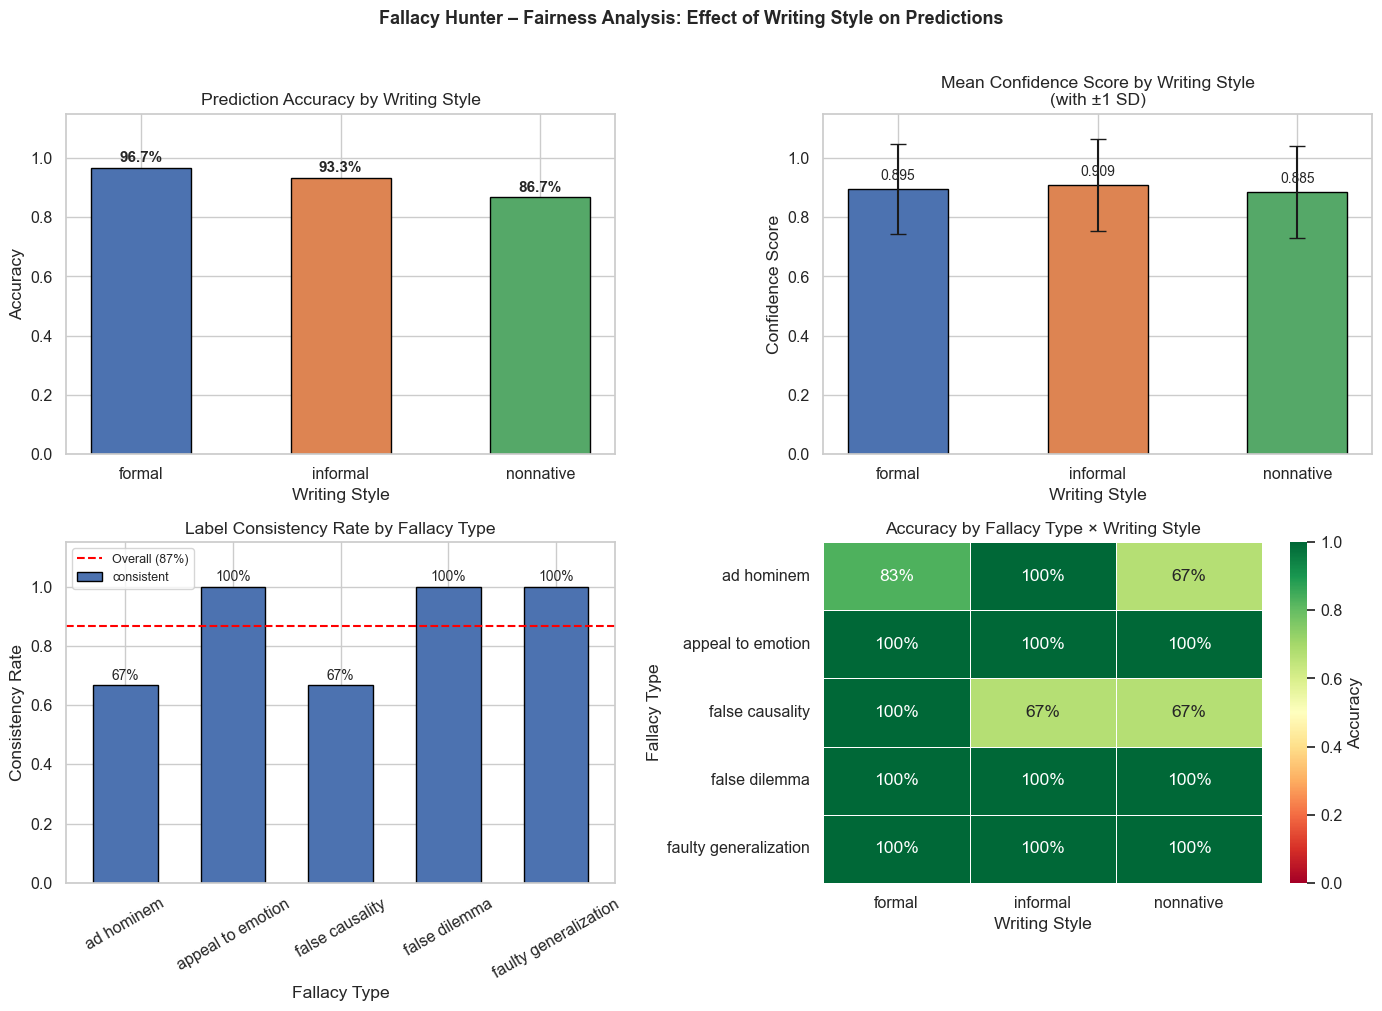

✓ fairness_analysis_charts.png saved


In [12]:
palette = [COLORS[s] for s in STYLES]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Fallacy Hunter – Fairness Analysis: Effect of Writing Style on Predictions',
    fontsize=13, fontweight='bold', y=1.01
)

# ── Chart 1: Accuracy by style ────────────────────────────────────
ax = axes[0,0]
vals = [acc.loc[s,'accuracy'] if s in acc.index else 0 for s in STYLES]
bars = ax.bar(STYLES, vals, color=palette, edgecolor='black', width=0.5)
ax.set_title('Prediction Accuracy by Writing Style')
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.15); ax.set_xlabel('Writing Style')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.02, f'{v:.1%}',
            ha='center', fontsize=11, fontweight='bold')

# ── Chart 2: Confidence by style ──────────────────────────────────
ax = axes[0,1]
conf_stats = res.groupby('style')['confidence'].agg(['mean','std'])
means = [conf_stats.loc[s,'mean'] if s in conf_stats.index else 0 for s in STYLES]
stds  = [conf_stats.loc[s,'std']  if s in conf_stats.index else 0 for s in STYLES]
bars = ax.bar(STYLES, means, yerr=stds, color=palette, edgecolor='black',
              capsize=6, width=0.5, error_kw={'linewidth':1.5})
ax.set_title('Mean Confidence Score by Writing Style\n(with ±1 SD)')
ax.set_ylabel('Confidence Score'); ax.set_ylim(0, 1.15); ax.set_xlabel('Writing Style')
for bar, m in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, m+0.03, f'{m:.3f}', ha='center', fontsize=10)

# ── Chart 3: Consistency by fallacy type ──────────────────────────
ax = axes[1,0]
by_ft_num = consistency.groupby('fallacy_type')['consistent'].mean()
by_ft_num.plot(kind='bar', ax=ax, color='#4C72B0', edgecolor='black', width=0.6)
ax.axhline(overall, color='red', linestyle='--', lw=1.5, label=f'Overall ({overall:.0%})')
ax.set_title('Label Consistency Rate by Fallacy Type')
ax.set_ylabel('Consistency Rate'); ax.set_ylim(0, 1.15)
ax.set_xlabel('Fallacy Type'); ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=9)
for i, v in enumerate(by_ft_num):
    ax.text(i, v+0.02, f'{v:.0%}', ha='center', fontsize=10)

# ── Chart 4: Accuracy heatmap ─────────────────────────────────────
ax = axes[1,1]
pivot_ordered = pivot.reindex(columns=STYLES)
sns.heatmap(pivot_ordered.round(2), ax=ax, annot=True, fmt='.0%',
            cmap='RdYlGn', vmin=0, vmax=1, linewidths=0.5,
            cbar_kws={'label':'Accuracy'})
ax.set_title('Accuracy by Fallacy Type × Writing Style')
ax.set_xlabel('Writing Style'); ax.set_ylabel('Fallacy Type')
ax.tick_params(axis='x', rotation=0); ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('fairness_analysis_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fairness_analysis_charts.png saved')

---
## 7 · Summary for report
This cell prints a plain-language summary you can use as a **starting point** to write your Results section — remember to put everything in your own words.

In [13]:
anova_sig  = p_anova < ALPHA
chi_sig    = p_chi   < ALPHA
acc_vals   = {s: acc.loc[s,'accuracy'] if s in acc.index else 0 for s in STYLES}
conf_means = {s: conf_stats.loc[s,'mean'] if s in conf_stats.index else 0 for s in STYLES}

print('═'*60)
print('  EXPERIMENT SUMMARY  (write this in your own words)')
print('═'*60)
print(f'''
Test data   : 90 arguments across 5 fallacy types × 3 writing styles
              (formal, informal, non-native English)

LABEL CONSISTENCY
  {overall:.1%} of argument groups received identical predicted labels
  across all three style variants.
  Lowest consistency: {consistency.groupby("fallacy_type")["consistent"].mean().idxmin()}
  Highest consistency: {consistency.groupby("fallacy_type")["consistent"].mean().idxmax()}

CONFIDENCE SCORES
  Formal   : {conf_means["formal"]:.3f}
  Informal : {conf_means["informal"]:.3f}
  Nonnative: {conf_means["nonnative"]:.3f}
  ANOVA result: F={f_stat:.3f}, p={p_anova:.4f} → {"SIGNIFICANT" if anova_sig else "not significant"}

PREDICTION ACCURACY
  Formal   : {acc_vals["formal"]:.1%}
  Informal : {acc_vals["informal"]:.1%}
  Nonnative: {acc_vals["nonnative"]:.1%}
  Chi-square: χ²={chi2:.3f}, p={p_chi:.4f} → {"SIGNIFICANT" if chi_sig else "not significant"}
  Cramér's V: {cramers_v:.3f}

INCONSISTENT GROUPS: {len(bad)}
  {bad if bad else "None — all groups predicted same label across styles"}
''')
print('═'*60)

════════════════════════════════════════════════════════════
  EXPERIMENT SUMMARY  (write this in your own words)
════════════════════════════════════════════════════════════

Test data   : 90 arguments across 5 fallacy types × 3 writing styles
              (formal, informal, non-native English)

LABEL CONSISTENCY
  86.7% of argument groups received identical predicted labels
  across all three style variants.
  Lowest consistency: ad hominem
  Highest consistency: appeal to emotion

CONFIDENCE SCORES
  Formal   : 0.895
  Informal : 0.909
  Nonnative: 0.885
  ANOVA result: F=0.186, p=0.8305 → not significant

PREDICTION ACCURACY
  Formal   : 96.7%
  Informal : 93.3%
  Nonnative: 86.7%
  Chi-square: χ²=2.169, p=0.3381 → not significant
  Cramér's V: 0.155

INCONSISTENT GROUPS: 4
  ['ah_04', 'ah_06', 'fc_04', 'fc_05']

════════════════════════════════════════════════════════════
